## Background and Motivation

There is not a unified, publicly available database of operational or legacy oil and gas well sites in Canada's north.  This presents a challenge for local governments, regulators, and academics wishing to understand hazards associated with oil and gas infrastructure.  This issue is particularly notable within the Inuvialuit Settlement Region (ISR), which seems to exist within an information "black hole" in regards to well locations, despite decades of oil and gas exploration in the area.  While the because the NWT Office of the Regulator of Oil and Gas Operations (OROGO) does maintain the publicly accessible [OROGO Well Status](https://www.orogo.gov.nt.ca/en/orogo-well-status) database, OROGO does not have jurisdiction over the ISR.  The Canadian Energy Regulator has jurisdiction over well site data in the region, however however the majority of wells in the ISR has been excluded from their publicly accessible [Basin Database](https://basin.marine-geo.canada.ca/index_e.php).  Here, we present a synthesis of CER records for the ISR with publicly available records to yield the most comprehensive dataset of well sites in Northern Canada.

In [25]:
import os
import sys
import numpy as np
import pandas as pd
import geopandas as gpd
from matplotlib import pyplot as plt
from rapidfuzz import fuzz
from itertools import combinations
from shapely.geometry import MultiPoint
from geopy import distance
from shapely import Point

from rapidfuzz import fuzz
from itertools import combinations
from shapely.geometry import multipoint
from scipy.spatial.distance import pdist

# NWT Databases

## OROGO

In [26]:
# OROGO database
OROGO = pd.read_csv('source_data/wells/NWT/orogo-well-status-updated-2026-04-10.csv').drop(columns=['NAD 27 Lat','NAD 27 Long','Unnamed: 16','Unnamed: 17']).dropna(how='all')
OROGO = gpd.GeoDataFrame(data=OROGO,geometry=gpd.points_from_xy(x=OROGO['NAD_83_LongDD'],y=OROGO['NAD_83_LatDD']),crs='NAD1983')
OROGO['Name'] = OROGO['Well Name'].str.upper()
OROGO = OROGO.set_index('Name',drop=False)
OROGO = OROGO.drop(columns='geometry')
OROGO[['y','x']] = OROGO[['NAD_83_LatDD', 'NAD_83_LongDD']]
OROGO['DS_UID'] = [f'OROGO-{i}' for i in range(0,len(OROGO))]
OROGO['First SPUD year'] = pd.to_datetime(OROGO['First SPUD year'],format='%Y')
print(len(OROGO))
print(OROGO.columns)

685
Index(['Well ID', 'Well Name', 'Last Operator', 'Current or Last Owner',
       'Well Status', 'Classification', 'First SPUD year',
       'Latest SPUD or Start Date', 'Latest Rig Release or End Date',
       'Land Title', 'Region', 'NAD_83_LatDD', 'NAD_83_LongDD', 'UWI', 'Name',
       'y', 'x', 'DS_UID'],
      dtype='str')


## NTGS Open Report 2009-03

In [27]:
NTGS_2009_03 = [r'source_data\wells\NWT\2009-03_Well_Sites\Well_Sites.shp',r'source_data\wells\NWT\2009-03_Well_Sites\Well_Sites_Peripheral.shp']
NTGS_2009_03 = pd.concat([gpd.read_file(fn).set_index('UWI') for fn in NTGS_2009_03]).to_crs('NAD1983')
# Fix a typo
NTGS_2009_03['WELL_NAME']=NTGS_2009_03['WELL_NAME'].str.replace('S. Tuttle YT -05','S. Tuttle YT N-05')
NTGS_2009_03['WELL_NAME']=NTGS_2009_03['WELL_NAME'].str.replace('Peel R ','Peel River ').str.replace('Peel R. ','Peel River ')
NTGS_2009_03['WELL_NAME']=NTGS_2009_03['WELL_NAME'].str.replace('Crown Bell River "YT-A" No.1 (N-50)','Crown Bell River "YT-A" No.1 N-50')
NTGS_2009_03['Name'] = NTGS_2009_03['WELL_NAME'].str.upper()
NTGS_2009_03['NAD_83_LatDD'] = NTGS_2009_03.geometry.y
NTGS_2009_03['NAD_83_LongDD'] = NTGS_2009_03.geometry.x
NTGS_2009_03 = NTGS_2009_03.reset_index().set_index('Name',drop=False)
NTGS_2009_03 = NTGS_2009_03.drop(columns='geometry')
NTGS_2009_03[['y','x']] = NTGS_2009_03[['NAD_83_LatDD', 'NAD_83_LongDD']]
NTGS_2009_03['DS_UID'] = [f'NTGS_2009_03-{i}' for i in range(0,len(NTGS_2009_03))]
NTGS_2009_03['SPUD_DATE'] = pd.to_datetime(NTGS_2009_03['SPUD_DATE'])
print(len(NTGS_2009_03))
print(NTGS_2009_03.columns)

549
Index(['UWI', 'WID', 'WELL_NAME', 'OPERATOR', 'STATUS', 'CLASSIFICA',
       'SPUD_DATE', 'RIG_RELEAS', 'LAT', 'LONG', 'DATUM', 'NORTHING',
       'EASTING', 'ZONE', 'SOURCE', 'REFERENCE', 'Name', 'NAD_83_LatDD',
       'NAD_83_LongDD', 'y', 'x', 'DS_UID'],
      dtype='str')


## NTGS Open Report 2019-015

In [28]:
# Report 2019-015
NTGS_2019_015_g = gpd.read_file(r'source_data\wells\NWT\2019-015_Shapefiles\Gas_Resource.shp').set_index('Well_Names',drop=False).rename(columns={'Recoverabl':'Recoverabl_gas'})
NTGS_2019_015_o = gpd.read_file(r'source_data\wells\NWT\2019-015_Shapefiles\Oil_Resource.shp').set_index('Well_Names',drop=False).rename(columns={'Recoverabl':'Recoverabl_oil'})

NTGS_2019_015 = pd.concat([
    NTGS_2019_015_g,
    NTGS_2019_015_o.loc[~NTGS_2019_015_o.index.isin(NTGS_2019_015_g.index),NTGS_2019_015_o.columns[NTGS_2019_015_o.columns!='Recoverabl_oil']]
]).to_crs('NAD1983')
NTGS_2019_015 = NTGS_2019_015.join(NTGS_2019_015_o[['Recoverabl_oil']],how='left')
NTGS_2019_015['NAD_83_LatDD'] = NTGS_2019_015.geometry.y
NTGS_2019_015['NAD_83_LongDD'] = NTGS_2019_015.geometry.x
NTGS_2019_015 = NTGS_2019_015.drop(columns='geometry')
NTGS_2019_015[['y','x']] = NTGS_2019_015[['NAD_83_LatDD', 'NAD_83_LongDD']]
# Fix a typos
NTGS_2019_015['Well_Names']=NTGS_2019_015['Well_Names'].str.replace('Ya Ya','YaYa')
NTGS_2019_015['Well_Names']=NTGS_2019_015['Well_Names'].str.replace('Tarsuit','Tarsiut')
NTGS_2019_015['Well_Names']=NTGS_2019_015['Well_Names'].str.replace('Koakaok','Koakoak')

NTGS_2019_015['Name'] = NTGS_2019_015['Well_Names'].str.upper()
NTGS_2019_015 = NTGS_2019_015.set_index('Name',drop=False)

NTGS_2019_015 = NTGS_2019_015.sort_index()
NTGS_2019_015 = NTGS_2019_015.loc[~NTGS_2019_015[['UWI']].duplicated(keep='first')]
NTGS_2019_015['DS_UID'] = [f'NTGS_2019_015-{i}' for i in range(0,len(NTGS_2019_015))]
NTGS_2019_015['Discovery'] = pd.to_datetime(NTGS_2019_015['Discovery'],format='%Y')

NTGS_2019_015

print(len(NTGS_2019_015))
# print(NTGS_2019_015.columns)

167


# Yukon Data

In [29]:
GeoYukon = gpd.read_file(r'source_data\wells\yukon\Oil_and_Gas_Wells_50k.shp').to_crs('NAD1983').rename(columns={'WELL_UWI':'UWI'})
GeoYukon['DATE'] = GeoYukon['DATE'].replace('0000/00/00',pd.NaT)
GeoYukon['DATE'] = pd.to_datetime(GeoYukon['DATE'])
# Fix a typo
GeoYukon['WELL_NAME'] = GeoYukon['WELL_NAME'].str.replace('Peel R ','Peel River ').str.replace('Peel R. ','Peel River ')
GeoYukon['WELL_NAME'] = GeoYukon['WELL_NAME'].str.replace('Shell ','')
GeoYukon['WELL_NAME'] = GeoYukon['WELL_NAME'].str.replace('Amerada et al Crown','Crown Bell River')
GeoYukon['WELL_NAME'] = GeoYukon['WELL_NAME'].str.replace('Amoco PCP B-1 Cranswick YT A-42','Cranswick YT A-42')

GeoYukon['Name'] = GeoYukon['WELL_NAME'].str.upper()
GeoYukon = GeoYukon.set_index('Name',drop=False)
GeoYukon['NAD_83_LatDD'] = GeoYukon.geometry.y
GeoYukon['NAD_83_LongDD'] = GeoYukon.geometry.x
GeoYukon = GeoYukon.drop(columns='geometry')
GeoYukon[['y','x']] = GeoYukon[['NAD_83_LatDD', 'NAD_83_LongDD']]
GeoYukon['DS_UID'] = [f'GeoYukon-{i}' for i in range(0,len(GeoYukon))]
print(len(GeoYukon))

76


# Federal Data

## Basin

In [30]:
Basin = pd.read_csv('source_data/wells/Basin/BASIN_well_coords.txt',delimiter='\t',skiprows=3).drop(columns=['Latitude (NAD27)','Longitude (NAD27)','Northing (NAD27)','Easting (NAD27)'])
Basin2 = pd.read_csv('source_data/wells/Basin/q1787332704.txt',delimiter='\t',skiprows=3).rename(columns={'Unique Well Identifier':'UWI'})
Basin2['UWI'] = Basin2['UWI'].str.replace(' ','')
Basin = pd.merge(Basin,Basin2[['Well Name','GSC #','Original Spud Year','Operator','Status','UWI']],on='Well Name',how='left')#.set_index('UWI')
Basin['Name'] = Basin['Well Name'].str.upper()
Basin = Basin.set_index('Name',drop=False)
Basin = Basin.sort_values(by='Original Spud Year')
Basin = Basin.loc[~Basin[['Name','UWI']].duplicated(keep='first')].copy()
Basin = Basin.loc[Basin['Latitude (NAD83)']>60]
Basin[['y','x']] = Basin[['Latitude (NAD83)', 'Longitude (NAD83)']]
Basin['DS_UID'] = [f'Basin-{i}' for i in range(0,len(Basin))]
Basin['Original Spud Year'] = pd.to_datetime(Basin['Original Spud Year'],format='%Y')
print(len(Basin))
print(Basin.columns)

179
Index(['Well Name', 'Basin', 'Subbasin', 'Latitude (NAD83)',
       'Longitude (NAD83)', 'Northing (NAD83)', 'Easting (NAD83)',
       'Zone (UTM)', 'GSC #', 'Original Spud Year', 'Operator', 'Status',
       'UWI', 'Name', 'y', 'x', 'DS_UID'],
      dtype='str')


## CER

* Missing UWI

In [31]:
CER1 = pd.read_csv(r'source_data\wells\CER\Frontier_Wells_Inuvik_Region.csv')
#Fi1x Typo
CER1['WELL_NAME']=CER1['WELL_NAME'].str.replace('AMAULIGAK CH NO.1','AMAULIGAK COREHOLE NO.1')
CER1['Name'] = CER1['WELL_NAME'].str.upper()
CER1['UWI'] = None
CER1 = CER1.set_index('Name',drop=False)
CER1[['y','x']] = CER1[['NAD_83_LAT', 'NAD_83_LON']]


CER2 = pd.read_csv(r'source_data\wells\CER\Copy of Frontier Data Base Well Info.csv')
NAD83 = CER2.loc[CER2['NAD 83 Lat'].notna()].copy()
NAD27 = CER2.loc[CER2['NAD 83 Lat'].isna()].copy()

for c in ['NAD 83 Lat','NAD 83 Long']:
    DMS = pd.DataFrame(NAD83[c].replace(r'[^0-9.]',' ',regex=True).str.split().to_list(),columns=['D','M','S'],index=NAD83['Well Name'])
    NAD83[c] = (DMS['D'].astype('float')+DMS['M'].astype('float')/60+DMS['S'].astype('float')/3600).values
    
for c in ['NAD 27 Lat','NAD 27 Long']:
    DMS = pd.DataFrame(NAD27[c].replace(r'[^0-9.]',' ',regex=True).str.split().to_list(),columns=['D','M','S'],index=NAD27['Well Name'])
    NAD27[c] = (DMS['D'].astype('float')+DMS['M'].astype('float')/60+DMS['S'].astype('float')/3600).values

NAD83 = gpd.GeoDataFrame(data=NAD83,geometry=gpd.points_from_xy(x=-1*NAD83['NAD 83 Long'],y=NAD83['NAD 83 Lat']),crs='NAD1983')
NAD27 = gpd.GeoDataFrame(data=NAD27,geometry=gpd.points_from_xy(x=-1*NAD27['NAD 27 Long'],y=NAD27['NAD 27 Lat']),crs='NAD1927').to_crs('NAD1983')
CER2 = pd.concat([NAD83,NAD27])
CER2['y'] =CER2.geometry.y
CER2['x'] =CER2.geometry.x

CER2['Name'] = CER2['Well Name'].str.upper()
CER2 = CER2.set_index('Name',drop=False)

CER1 = CER1.rename(columns={'OPERATOR':'Well Operator', 'STATUS':'Well Status','REGION':'Region'})

CER = pd.concat([CER2,CER1.loc[~CER1.index.isin(CER2.index),CER1.columns]]).sort_index()
CER['DS_UID'] = [f'CER-{i}' for i in range(0,len(CER))]

#Fix a typo
CER['Name'] = CER['Name'].str.replace('CROSSLEY LK','CROSSLEY LAKE')

print(len(CER))
print(CER2.columns)

1604
Index(['Well ID', 'Well Name', 'UWI', 'Well Operator', 'Well Status',
       'Classification', 'SPUD Date', 'Rig Release Date', 'Land Title',
       'Region', 'NAD 27 Lat', 'NAD 27 Long', 'NAD 83 Lat', 'NAD 83 Long',
       'geometry', 'y', 'x', 'Name'],
      dtype='str')


## GSC Open Files 

* some missing key identifiers, so pre-synthesis needed for better record matching

## GSC Open File 6959

In [32]:
GSC_6959 = pd.read_csv(r'source_data\wells\GSC\GSC_OF_6959.csv')#@.set_index('UWI')
GSC_6959['Name'] = GSC_6959['Well Short Name'].str.upper()
GSC_6959=GSC_6959.set_index('Name',drop=False)
GSC_6959[['y','x']] = GSC_6959[['SURF_LAT', 'SURF_LONG']]
GSC_6959['DS_UID'] = [f'GSC_6959-{i}' for i in range(0,len(GSC_6959))]
#Fix typo
GSC_6959['Name'] = GSC_6959['Name'].str.replace('BEAVERHOUSE','BEAVER HOUSE')
print(len(GSC_6959))
print(GSC_6959.columns)

265
Index(['UWI', 'Well Short Name', 'EASTING', 'NORTHING', 'MAP_DATUM',
       'SURF_LAT', 'SURF_LONG', 'UTMZONE', 'Well Status', 'KB (m)', 'GL (m)',
       'Final Interpretation, Ice-bearing permafrost base, Base of fully frozen (mKB)',
       'Final Interpretation Ice-bearing permafrost base Base of fully frozen (mGL/SF)',
       'Final Interpretation Ice-bearing permafrost base Quality', 'Formation',
       'Final Interpretation Ice-bearing permafrost base Base of partially frozen (mKB)',
       'Final Interpretation Ice-bearing permafrost base Base of partially frozen (mGL/SF)',
       'Final Interpretation Ice-bearing permafrost base Quality.1',
       'Final Interpretation Ice-bearing permafrost base Transition zone thickness (m)',
       'Final Interpretation Ice-bearing permafrost base Formation/ Sequence ',
       'Final Interpretation Ice-bearing permafrost base PF present',
       'Final Interpretation Ice-bearing permafrost base Data used for final pick*',
       'Base of 

## GSC Open File 4828 & 327948

In [33]:
# Missing UWI
GSC_4828 = pd.read_csv(r'source_data\wells\GSC\GSC_OF_4828.csv')
for c in ['Latitude', 'Longitude']:
    DMS = pd.DataFrame(GSC_4828[c].replace(r'[^0-9.]',' ',regex=True).str.split().to_list(),columns=['D','M','S'],index=GSC_4828['Well Name'])
    GSC_4828[c] = (DMS['D'].astype('float')+DMS['M'].astype('float')/60+DMS['S'].astype('float')/3600).values
GSC_4828['Longitude'] *= -1
GSC_4828['Name'] = GSC_4828['Well Name'].str.upper()
GSC_4828 = GSC_4828.set_index('Name',drop=False)
GSC_4828[['y','x']] = GSC_4828[['Latitude', 'Longitude']]

# Fix a typo
GSC_4828.loc[GSC_4828['Name'] == 'REINDEER F-36','Name'] = 'REINDEER C-36'
GSC_4828['Name'] = GSC_4828['Name'].str.replace('BEAVERHOUSE','BEAVER HOUSE')

# # Missing coordinates but contains UWI
GSC_327948 = pd.read_csv(r'source_data\wells\GSC\GSC_OF_327948.csv')
GSC_327948['Name'] = GSC_327948['Well name'].str.upper()
GSC_327948 = GSC_327948.set_index('Name',drop=False)
GSC_327948 = GSC_327948.loc[GSC_327948['UWI'].duplicated(keep='first')].copy()
GSC_327948[['x','y']] = None,None
# Get from GSC_6959 & 327948
GSC_4828=GSC_4828.join(GSC_6959[['UWI']],how='left')
for k,v in GSC_4828.loc[GSC_4828['UWI'].isna(),'Name'].isin(GSC_327948['Name']).items():
    if v:
        GSC_4828.loc[GSC_4828.index==k,'UWI'] = GSC_327948.loc[GSC_327948.index==k,'UWI']
GSC_4828['DS_UID'] = [f'GSC_4828-{i}' for i in range(0,len(GSC_4828))]
GSC_327948['DS_UID'] = [f'GSC_327948-{i}' for i in range(0,len(GSC_327948))]
print(len(GSC_4828))
print(GSC_4828.columns)

print(len(GSC_327948))
print(GSC_327948.columns)


263
Index(['Well No.', 'Company', 'Well Name', 'Latitude', 'Longitude', 'KBm',
       'GLm', 'TD(ft)', 'TD(m)', 'TVD', 'Name', 'y', 'x', 'UWI', 'DS_UID'],
      dtype='str')
40
Index(['UWI', 'Well name', 'Top of overpressure zone mSl',
       'Top of overpressure zone mGl', 'Top of overpressure zone quality',
       'Sequence', 'Comments', 'Name', 'x', 'y', 'DS_UID'],
      dtype='str')


# Consultant Reports

## Arktis report for ILA

In [34]:
ILA = pd.read_csv(r'source_data\wells\ISR\ISR_well_report_B1.csv')
ILA = ILA.loc[~ILA['Latitude (NAD83) -Well Post'].isna()].copy()
for c in ['Latitude (NAD83) -Well Post','Longitude (NAD83) -Well Post']:
    DMS = pd.DataFrame(ILA[c].replace(r'[^0-9.]',' ',regex=True).str.split().to_list(),columns=['D','M','S'],index=ILA['Well Name'])
    ILA[c] = (DMS['D'].astype('float')+DMS['M'].astype('float')/60+DMS['S'].astype('float')/3600).values
ILA['Longitude (NAD83) -Well Post'] *= -1

#Fix typo
ILA['Well Name'] = ILA['Well Name'].str.replace('CROSSLEY LK','CROSSLEY LAKE')
ILA['Well Name'] = ILA['Well Name'].str.replace('ATERTAK K-31','ATERTAK L-31')


ILA['Name'] = ILA['Well Name'].str.upper()
ILA = ILA.set_index('Name',drop=False)
ILA[['y','x']] = ILA[['Latitude (NAD83) -Well Post','Longitude (NAD83) -Well Post']]

ILA['Original Spud Date'] = pd.to_datetime(ILA['Original Spud Date'],format="%d-%b-%y",errors='coerce').map(lambda x: x.replace(year=x.year - 100) if x.year >= 2040 else x)
ILA['DS_UID'] = [f'ILA-{i}' for i in range(0,len(ILA))]
print(len(ILA))
print(ILA.columns)

227
Index(['WID', 'Consortium', 'Current Owner', 'Land Owner', 'Well Name', 'UWI',
       'Class', 'Status', 'Latitude (NAD83) -Well Post',
       'Longitude (NAD83) -Well Post', 'Region', 'Original Spud Date',
       'Original Rig Release Date', 'Depth (m)', 'Notes', 'Name', 'y', 'x',
       'DS_UID'],
      dtype='str')


## LTLC Report

In [35]:
LTLC = pd.read_csv('source_data/wells/misc/LTLC_report.csv')
LTLC = LTLC.set_index('Name',drop=False)
LTLC['UWI'] = None
LTLC[['x','y']] = None,None


LTLC['Spud_Date'] = pd.to_datetime(LTLC['Spud_Date'])
LTLC['DS_UID'] = [f'LTLC-{i}' for i in range(0,len(LTLC))]
print(len(LTLC))
print(LTLC.columns)

92
Index(['Name', 'Operator', 'Spud_Date', 'RIG RELEASE', 'DRILLING PLATFORM',
       'WATER DEPTH (M)', 'UWI', 'x', 'y', 'DS_UID'],
      dtype='str')


# Aggregating

In [36]:

def dfilter(X,mask):
	out = {key:value for key,value in X.items() if key not in mask and value not in mask}
	if len(out) == 1:
		out = list(out.values())[0]
	return(out)	

def filter(X,mask=['None','NONE',None,np.nan],fuzzmask=None):
    if type(X) is dict:
        return(dfilter(X,mask))
    elif type(X) is list:
        out = [x for x in X if x not in mask]
        if len(out) == 0:
            return (None)
        elif len(out)==1:
            return(out[0])
        elif fuzzmask is None:
            return(out)
        else:
            fuzzyMin = min([fuzz.partial_ratio(c[0],c[1]) for c in combinations(out,2)])
            if fuzzyMin>=fuzzmask:
                out.sort()
                out = out[0]
            return(out)
    else:
        return(X)

def listCheck(X,contains=None):
	if contains is None:
		return(type(X) is list)
	else:
		if type(X) is list:
			any([x in contains for x in X])
		else:
			return(False)


def lcat(lx):
    # concatenate list of sublist to list
    l = []
    for ly in lx:
        for y in ly:
            l.append(y)
    return(l)

def dispersion(xy):
    cx = list(combinations([(x,y) for x,y in zip (xy['x'],xy['y'])],r=2))
    if not len(cx):
        return(0)
    else:
        d = np.array([distance.distance(p1[::-1],p2[::-1],ellipsoid='WGS-84').meters for p1,p2 in cx])
        return(d.std())

# Combine records

First step is to fill missing UWI values

In [37]:
dataSet = {
'OROGO':OROGO,
'NTGS_2009_03':NTGS_2009_03,
'NTGS_2019_015':NTGS_2019_015,
'GeoYukon':GeoYukon,
'Basin':Basin,
'CER':CER,
'GSC_327948':GSC_327948,
'GSC_4828':GSC_4828,
'GSC_6959':GSC_6959,
'ILA':ILA,
'LTLC':LTLC
}

columns_by_source = {
	'Company':{
		'OROGO':'Current or Last Owner',
		'NTGS_2009_03':'OPERATOR',
		'NTGS_2019_015':None,
		'GeoYukon':'LICENSEE',
		'Basin':'Operator',
		'CER':'Well Operator',
		'GSC_327948':None,
		'GSC_4828':'Company',
		'GSC_6959':None,
		'ILA':'Current Owner',
		'LTLC':'Operator'
			},
	'Spud_Year':{
		'OROGO':'First SPUD year',
		'NTGS_2009_03':'SPUD_DATE',
		'NTGS_2019_015':'Discovery',
		'GeoYukon':'DATE',
		'Basin':'Original Spud Year',
		'CER':'SPUD Date',
		'GSC_327948':None,
		'GSC_4828':None,
		'GSC_6959':None,
		'ILA':'Original Spud Date',
		'LTLC':'Spud_Date'
	},
	'Status':{
		'OROGO':'Well Status',
		'NTGS_2009_03':'STATUS',
		'NTGS_2019_015':None,
		'GeoYukon':'STATUS',
		'Basin':'Status',
		'CER':'Well Status',
		'GSC_327948':None,
		'GSC_4828':None,
		'GSC_6959':'Well Status',
		'ILA':'Status',
		'LTLC':None
	},
}

# Corrections
for key,value in dataSet.items():
    df = dataSet[key]
    # A UID for backtracking all records
    df['Data_Source'] = key
    df.loc[df['UWI'].str.len()<16,'UWI']=None
    df['UWI'] = df['UWI'].fillna('None').astype('str').str.lstrip()
    df['FullName'] = df['Name'].copy()
    # Removed secondary codes
    df['Code_alt'] = df['Name'].str.extract(r".*(\d[a-zA-Z]-\d+[a-zA-Z]{,})").fillna(df['Name'].str.extract(r".*([a-zA-Z]-\d+[a-zA-Z]{,})")).fillna('~')
    df['Name'] = df['Name'].str.split(r'(').str[0]
    df['Code'] = df['Name'].str.extract(r".*(\d[a-zA-Z]-\d+[a-zA-Z]{,})").fillna(df['Name'].str.extract(r".*([a-zA-Z]-\d+[a-zA-Z]{,})"))
    df['Code'] = df['Code'].fillna(df['Code_alt'])
    df['Short_Name'] = [t.split(n)[0] if t.split(n)[0] != '' else t.split(n)[-1] for t,n in zip(df['Name'],df['Code'])]
    df['Short_Name'] = df['Short_Name'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True).str.rstrip()
    df['Name'] = df['FullName']
    for k,v in columns_by_source.items():
        if v[key] is None or v[key] not in df.columns:
            df[k] = v[key]
        else:
            df[k] = df[v[key]]

# First pass merge
AllPoints = pd.concat([d[['FullName','Name','Short_Name','Code','Code_alt','UWI','Data_Source','DS_UID','x','y']+list(columns_by_source.keys())] for d in dataSet.values()])
# AllPoints = gpd.GeoDataFrame(data=AllData,geometry=gpd.points_from_xy(x=AllData['x'],y=AllData['y']),crs='NAD1983').to_crs('WGS1984')
AllPoints['OID'] = [i for i in range(0,len(AllPoints))]
AllPoints = AllPoints.set_index('DS_UID')
# Round to ~1.1m (remove floating point issues when doing comparisons)
AllPoints[['x','y']] = AllPoints[['x','y']].round(5).astype('float32')

AllPoints['UWI_clip'] = AllPoints['UWI'].str[:15]
UWI_clip_reps = AllPoints.loc[AllPoints['UWI']!='None'].groupby(['UWI_clip','Short_Name','Code']).agg(set)['UWI'].apply(len)
print(f'Total replicated Short_Name:Code pairs with with UWI that differ by only last digit: {len(UWI_clip_reps[UWI_clip_reps>1])} will be condensed by assuming last digit difference is an error or duplicate event')

nmg = 0
for UWI_clip,Short_Name,Code in UWI_clip_reps.loc[UWI_clip_reps>1].index:
    UWI = AllPoints.loc[((AllPoints['UWI_clip']==UWI_clip)&(AllPoints['Short_Name']==Short_Name)&(AllPoints['Code']==Code)),'UWI'].sort_values().values[0]
    nmg += len(AllPoints.loc[((AllPoints['UWI_clip']==UWI_clip)&(AllPoints['Short_Name']==Short_Name)&(AllPoints['Code']==Code)),'UWI'])
    AllPoints.loc[((AllPoints['UWI_clip']==UWI_clip)&(AllPoints['Short_Name']==Short_Name)&(AllPoints['Code']==Code)),'UWI'] = UWI

# Manual fix for problematic records
# Incorrect UWI (Lat indicated in original UWI is 70, but coords show 68, and this record matches other wells with same name)
AllPoints.loc[AllPoints.index.isin(['GSC_4828-261','GSC_6959-71']),'UWI'] = '300F296830134300'
# Code replicate improperly clipped
AllPoints.loc[((AllPoints['UWI']=='302C507010132300') & (AllPoints['Code']=='C-50')),'Code'] = '2C-50'
# Fix a discrepancy between CER and other records
AllPoints.loc[AllPoints['UWI']=='300K316940132300',['Name','Short_Name','Code']] = ['ATERTAK K-31','ATERTAK','K-31']

# Replicates that are not needed
AllPoints = AllPoints.loc[AllPoints['Name']!='AMAULIGAK 2F-24BST']


Total replicated Short_Name:Code pairs with with UWI that differ by only last digit: 141 will be condensed by assuming last digit difference is an error or duplicate event


In [38]:
UWI = AllPoints[AllPoints['UWI'] != 'None'].copy()
noUWI = AllPoints[AllPoints['UWI'] == 'None'].copy()
for i,row in noUWI[noUWI['Name'].isin(UWI['Name'])].iterrows():
    if len(UWI.loc[UWI['Name']==row['Name'],'UWI'].unique())>1:
        sys.exit('Replication issue')
    else:
        uwi = UWI.loc[UWI['Name']==row['Name'],'UWI'].unique()
        AllPoints.loc[AllPoints.index==i,'UWI'] = uwi
UWI = AllPoints[AllPoints['UWI'] != 'None'].copy()
noUWI = AllPoints[AllPoints['UWI'] == 'None'].copy()

# Create UWI or records without match
toMake = noUWI.loc[((noUWI['Code']!='~')&(noUWI['x'].notna()))].copy()
base = np.floor(toMake[['x','y']]).astype(int).astype(str)
mod = (toMake[['x','y']].mod(1)*60).astype(int).astype(str)
toMake['UWI'] = '300'
toMake.loc[toMake['Code'].str[0].str.isdigit(),'UWI'] = '30'
toMake['UWI'] = toMake['UWI']+toMake['Code'].str.replace('~','NAN').str.replace('-','')+base['y']+mod['y'].str.zfill(2)+base['x'].str[1:]+mod['x'].str.zfill(2)+'0'
# toMake['UWI']
for i,row in toMake.iterrows():
    AllPoints.loc[AllPoints.index == i,'UWI'] = row['UWI']

UWI = AllPoints[AllPoints['UWI'] != 'None'].copy()
noUWI = AllPoints[AllPoints['UWI'] == 'None'].copy()
for i,row in noUWI[noUWI['Name'].isin(UWI['Name'])].iterrows():
    if len(UWI.loc[UWI['Name']==row['Name'],'UWI'].unique())>1:
        sys.exit('Replication issue')
    else:
        uwi = UWI.loc[UWI['Name']==row['Name'],'UWI'].unique()
        AllPoints.loc[AllPoints.index==i,'UWI'] = uwi

# these will not be used
noUWI = AllPoints[AllPoints['UWI'] == 'None'].copy()

UWI = AllPoints[AllPoints['UWI'] != 'None'].reset_index().copy()

# Length of missing UWI values after matching
print(len(UWI),len(noUWI))



4137 8


In [39]:
def setCompanies(company,rep=None):
    if rep is None:
        rep = {
            'MARATHON':['CANADIAN FOREST'],
            'Dome':['DOME',"HUDSON'S BAY OIL",'HOME OIL'],
            'DEMINEX':['DEMINEX'],
            'MOBIL':['MOBIL','STANDARD','CANADIAN SUPERIOR'],
            'GSC':['JAPEX','AURORA COLLEGE'],
            'TRILLIUM':['TRILLIUM'],
            'INTER-CITY':['INTER-','WESTERN HOMESTEAD','CANADIAN HOMESTEAD'],
            'HUNT':['HUNT'],
            'ANDERSON':['ANDERSON','PC ANDERSON','COLUMBIA GAS'],
            'IMPERIAL OIL':['IMP','ESSO','NORTHWEST OILS','UNITED CANSO ','DOM.EXPLORERS-CANSO','I.O.E.'],
            'SHELL':['SHELL'],
            'CHEVRON':['CHEVRON','TEXACO','TEXCAN','HORN RIVER CCS GETTY','THE CALIFORNIA STANDARD','UNOCAL','CANADIAN RESERVE OIL AND GAS LTD'],
            'BP':['AMOCO','ATLANTIC RICHFIELD','BP','RICHFIELD OIL CORPORATION','ARCO','PAN AMERICAN','COLUMBIA ET AL AMOCO','B P O G'],
            'PARAMOUNT RESOURCES':['PARAMOUNT','MGM','APACHE '],
            'CENOVUS':['CENOVUS','HUSKY'],
            'CANADIAN NATURAL RESOURCES':['CANADIAN NATURAL RESOURCES','RANGER','DEVON','PC DEVON'],
            'ENCANA':['ENCANA','CANADIAN PACIFIC OIL & GAS','C.P.O.G.'],
            'TOTAL':['ELF','AQUITAINE','ELFEX','FRENCH PETROLEUM','TOTAL '],
            'CONOCOPHILLIPS':['CONOCO','GULF','PHILLIPS ','INEXCO OIL CO. AND HUSKY'],
            'SUNCOR ENERGY':['SUNCOR','PANARCTIC','B.A.','BRITISH AMERICAN','AMERADA','PETRO-CANADA ','PETROFINA ','HORN RIVER PANARCTIC','SUN','PC ','PACIFIC PETROLEUMS','PACIFIC ET AL.'],
            'OCCIDENTAL':['GREAT PLAINS','NORCERN','KERR '],
            'CANADIAN OIL SANDS':['CANADA SOUTHERN PETROLEUM LTD'],
            'INUVIALUIT PETROLEUM CORPORATION':['IPC','INUVIALUIT'],
            None:['NAN']
            }
    company = str(company).upper()
    for key,val in rep.items():
        if any([company.startswith(v) for v in val]):
            company = key
            break
    if company == '' or company == 'UNCERTAIN' or company is None or company == 'NONE':
        company = ''
    return(company)

def setStatus(stat):
    rep = {'P&A':'Abandoned','PLUG':'Abandoned','OTHER':'Abandoned','ABANDONED':'Abandoned','SUSP':'Suspended','OIL':'','GAS':'','INJECTOR':'','PRODUCER':'Suspended'}
    if not type(stat) is str:
        return('')
    for key,value in rep.items():
        if key in stat.upper():
            stat = value
            break
    return(stat)

def aggFunc(X):
    if X.name == 'Short_Name':
        X = list(set(X))
        if len(X)>1:
            X.sort()
        X = X[0]
    elif X.name == 'Code':
        X = list(set(X))
        if len(X)>1:
            if '~' in X:
                X.remove('~')
            X.sort()
        X = X[0]
    elif X.name == 'Data_Source':
        X = list(set([x.split('_')[0] for x in X]))
        X.sort()
        X = ';'.join(X)
    elif X.name == 'Company':
        X = ';'.join(list(set([setCompanies(x) for x in X])))
    elif X.name == 'Status':
        X = list(set([setStatus(x) for x in [x for x in X if ((type(x) is str) and (x is not None) and (x != 'None'))]]))
        X.sort()
        X = ';'.join(list(set(X)))
        if X == '':
            X = 'Abandoned'
    elif X.name == 'Spud_Year':
        X = pd.to_datetime([x for x in X if x is not None]).year.min()
    elif X.name == 'x':
        X = [x for x in X if not np.isnan(x)]
    elif X.name == 'y':
        X = [x for x in X if not np.isnan(x)]
    elif X.name == 'DS_UID':
        X = ';'.join(set(X))
    else:
        X = ';'.join(list(set([str(x) for x in X])))
    if type(X) is str:
        X = X.lstrip(';').rstrip(';')
    return(X)
print(UWI.columns)

WellSites=UWI[['UWI','DS_UID','OID','Short_Name','Code','Data_Source','Company','Spud_Year','Status','x','y']].groupby('UWI').agg(aggFunc)

UTM = pd.Series({
    7:-141,8:-135,9:-129,10:-123,11:-117,12:-111,13:-105,14:-99,15:-93,16:-87,17:-81,18:-75,19:-69,20:-63,21:-57
    })
def mp(XY):
    points = [(x,y) for x,y in zip(XY['x'],XY['y'])]
    points = MultiPoint(points)
    zone = UTM[(UTM-points.centroid.x).abs()==(UTM-points.centroid.x).abs().min()].index.values[0]
    zone = f'NAD83(CSRS) / UTM zone {zone}N'
    return([points,zone])
WellSites[['NAD1983_multipoint','UTM_Zone']] = WellSites[['x','y']].T.apply(mp).T
WellSites['NAD1983_centroid'] = None
WellSites['mean_coord_disp_UTM'] = np.nan
for zone in WellSites['UTM_Zone'].unique():
    LatLon = WellSites.loc[WellSites['UTM_Zone']==zone,'NAD1983_multipoint']
    proj = gpd.GeoSeries(LatLon,crs='NAD1983').to_crs(zone).geometry
    WellSites.loc[WellSites['UTM_Zone']==zone,'NAD1983_centroid'] = proj.centroid.to_crs('NAD1983')
    WellSites.loc[WellSites['UTM_Zone']==zone,'mean_coord_disp_UTM'] = np.array(
        [pdist([(g.x,g.y) for g in xy.geoms]).mean() if len(xy.geoms)>1 else np.nan for xy in proj.geometry]
        )
WellSites['replicates'] = WellSites['x'].apply(len)
WellSites = gpd.GeoDataFrame(data=WellSites.drop(columns=['x','y','NAD1983_multipoint']),geometry=WellSites['NAD1983_multipoint'],crs='NAD1983')
WellSites['NAD1983_centroid'] = gpd.GeoSeries(WellSites['NAD1983_centroid'],crs='NAD1983')
WellSites = WellSites.reset_index()
WellSites['Name'] = WellSites['Short_Name']+' '+WellSites['Code']
WellSites.loc[WellSites['Name'] == 'TUK M-18','Status'] = 'Under Development'
WellSites.loc[WellSites['Name'] == 'IKHIL K-35','Status'] = 'Suspended'
WellSites.loc[WellSites['Name'] == 'IKHIL J-35','Status'] = 'Producer'

WellSites['Status'].unique()

Index(['DS_UID', 'FullName', 'Name', 'Short_Name', 'Code', 'Code_alt', 'UWI',
       'Data_Source', 'x', 'y', 'Company', 'Spud_Year', 'Status', 'OID',
       'UWI_clip'],
      dtype='str')


<StringArray>
[          'Abandoned', 'Abandoned;Suspended',           'Suspended',
            'Producer',   'Under Development']
Length: 5, dtype: str

# Overwrite Verified Coordinates

In [40]:
GSC_site_visits = pd.read_csv(r'C:\Users\jskeeter\gsc-permafrost\WellSites\NorthernWellSites\source_data\wells\Visits\WellVisits.csv')
GSC_site_visits = gpd.GeoDataFrame(data=GSC_site_visits,geometry=gpd.points_from_xy(x=GSC_site_visits['Lon'],y=GSC_site_visits['Lat']),crs='WGS1984').to_crs(WellSites.crs)
GSC_site_visits['Date'] = pd.to_datetime(GSC_site_visits['Date'])

WellSites['Date_Validated'] = pd.NaT
for i,row in GSC_site_visits.iterrows():
    WellSites.loc[WellSites['UWI']==row['UWI'],'geometry'] = row['geometry']
    WellSites.loc[WellSites['UWI']==row['UWI'],'NAD1983_centroid'] = row['geometry']
    WellSites.loc[WellSites['UWI']==row['UWI'],'Date_Validated'] = row['Date']

<Axes: >

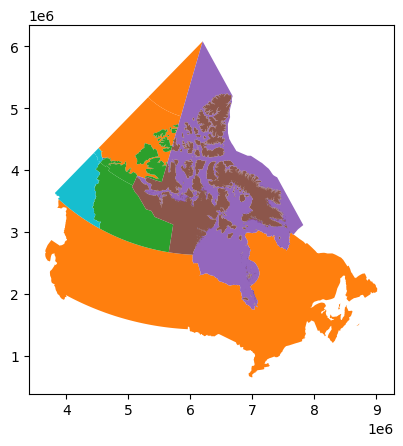

In [41]:
CA_Water = gpd.read_file('source_data/boundary/lpr_000a21a_e.shp')
# CA_Water = CA_Water.loc[CA_Water['PRUID'].isin(['60','61','62'])].copy()
CA_Land = gpd.read_file('source_data/boundary/lpr_000b16a_e.shp')
# CA_Land = CA_Land.loc[CA_Land['PRUID'].isin(['60','61','62'])].to_crs(CA_Water.crs)
Delta = gpd.read_file('source_data/boundary/delta.shp').to_crs(CA_Water.crs)
ISR = gpd.read_file('source_data/boundary/ISR_bounds.shp').to_crs(CA_Land.crs)
# Delta['Delta'] = 1
# ISR['ISR'] = 1
# CA_Land['Onshore'] = 1
# TC = [ISR[['ISR','geometry']].copy(),Delta[['Delta','geometry']].copy(),CA_Land.loc[CA_Land['PRUID'].isin(['60','61','62']),['Onshore','geometry']].copy()]
# ROI = CA_Water[['PRUID','PRNAME','geometry']].copy()
# clp = CA_Water.dissolve()
# for t in TC:
#     t = t.clip(clp)
#     ROI = gpd.overlay(ROI,t,how='union',keep_geom_type=True)
# ROI = ROI.loc[ROI.area>1e6]
# # Create regions in line with nomenclature CER usues
# ROI['ISR'] = ROI['ISR'].fillna(0)
# ROI['Delta'] = ROI['Delta'].fillna(0)
# ROI['Onshore'] = ROI['Onshore'].fillna(0)
# ROI['Region'] = 'NWT Offshore'
# ROI.loc[ROI['PRUID']=='60','Region'] = 'Yukon Offshore'
# ROI.loc[ROI['PRUID']=='62','Region'] = 'Nunavut Offshore'
# ROI.loc[((ROI['Delta'] == 1) & (ROI['Onshore'] == 0)),'Region'] = ROI.loc[((ROI['Delta'] == 1) & (ROI['Onshore'] == 0)),'Region'].str.replace('Offshore','Mackenzie Delta')
# ROI.loc[ROI['Onshore']==1,'Region'] = ROI.loc[ROI['Onshore']==1,'Region'].str.replace('Offshore','Onshore')
# ROI = ROI.dissolve(by=['Region','ISR']).reset_index()
# ROI.to_file('source_data/boundary/ROI.shp')
# Regions shapefile (created as above)
ROI = gpd.read_file('source_data/boundary/ROI.shp')
fig,ax=plt.subplots()
ROI.plot(ax=ax,column='Region')

In [ ]:

WellSites['Region'] = None
WellSites['ISR'] = False
CentrePoints = WellSites['NAD1983_centroid'].to_crs(ROI.crs)
for Region in ROI['Region'].unique():
    for isr in [1,0]:
        sel = ROI.loc[((ROI['Region']==Region)&(ROI['ISR']==isr))].dissolve().geometry
        if len(sel):
            ix = CentrePoints.within(sel.values[0])
            WellSites.loc[
                ix,'Region'
                ] = Region
            WellSites.loc[
                ix,'ISR'
                ] = bool(isr)
WellSites['Offshore'] = False
WellSites['Region'] = WellSites['Region'].fillna('Offshore Atlantic')
WellSites.loc[WellSites['Region'].str.contains('Offshore'),'Offshore'] = True
WellSites.loc[((WellSites['NAD1983_centroid'].y<72)&(
    (WellSites['Region'] == 'NWT Offshore')|
    (WellSites['Region'] == 'Yukon Offshore'))),'Region'] = 'Beaufort Sea'
WellSites.loc[((WellSites['NAD1983_centroid'].y>72)&(WellSites['Region'] == 'NWT Offshore')),'Region'] = 'NWT Arctic Islands Offshore'
WellSites.loc[((WellSites['NAD1983_centroid'].y>72)&(WellSites['Region'] == 'NWT Onshore')),'Region'] = 'NWT Arctic Islands Onshore'
WellSites.groupby(['Region','ISR']).count()['Name']
WellSites['ISR'].sum()


331

C:\Users\jskeeter\AppData\Local\Temp\ipykernel_37156\2508838769.py:6: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  WellSites[WellSites['Region'].isna()].to_crs(Delta.crs).plot(ax=ax,color='yellow')


Text(0.5, 1.0, 'Well Center Points')

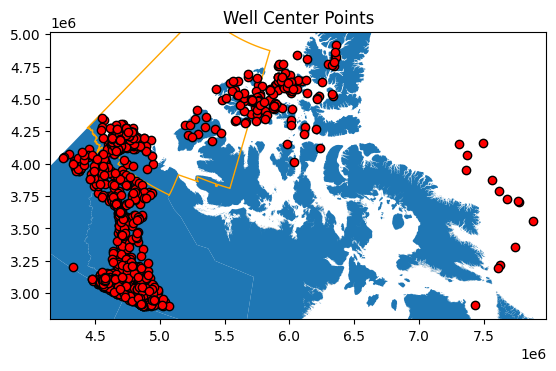

In [19]:

fig,ax=plt.subplots()
CA_Land.plot(ax=ax)
ISR.plot(ax=ax,color='None',edgecolor='orange')
Delta.plot(ax=ax,color='None',edgecolor='purple')
CentrePoints.to_crs(CA_Land.crs).plot(ax=ax,color='red',edgecolor='k')
WellSites[WellSites['Region'].isna()].to_crs(Delta.crs).plot(ax=ax,color='yellow')
blim = CentrePoints.buffer(1e5).total_bounds
ax.set_xlim(blim[0],blim[2])
ax.set_ylim(blim[1],blim[3])
ax.set_title('Well Center Points')



In [20]:
WellSites.groupby(WellSites['Data_Source']).count()['Name'].sort_values(ascending=False)

Data_Source
CER;OROGO               476
CER;NTGS                385
CER;NTGS;OROGO          188
CER;GSC;ILA             115
Basin;CER               100
CER                      74
CER;GSC;ILA;NTGS         59
CER;GSC;LTLC             47
CER;GSC;LTLC;NTGS        40
Basin                    40
Basin;CER;ILA            31
CER;GeoYukon;NTGS        27
CER;GeoYukon             25
GeoYukon                 21
OROGO                    17
CER;ILA                  13
NTGS                      4
CER;GSC;GeoYukon;ILA      3
CER;GSC;NTGS;OROGO        3
Basin;CER;ILA;NTGS        2
CER;ILA;NTGS              2
CER;GSC;ILA;LTLC          1
CER;LTLC                  1
CER;GSC;NTGS              1
GSC                       1
ILA                       1
Name: Name, dtype: int64

In [21]:
dest = '../LeakingWellSites/data'
WellSites['NAD1983_centroid'] = WellSites['NAD1983_centroid'].to_wkt()
for p in [os.getcwd(),dest]:
    if p is not None and os.path.isdir(p):
        out = os.path.join(p,'NorthernWellSites.json')
        if os.path.isfile(out):
            os.remove(out)
        WellSites.to_file(out,driver='geojson')

regroup by UWI